# GET 324 — Laboratory Exercise 10 (Mini-Project)
## Cloud Computing and AI Model Deployment for Engineering Applications
### Assigned Task (Group CV10): **Fresh Apple vs Rotten Apple** — Binary Image Classification

**Approach:** Transfer Learning with **MobileNetV2** (pre-trained on ImageNet), following the CNN /
Transfer Learning procedure from the GET324 AI/ML Practical Guide.

**Environment note:** This notebook is written to run on **Kaggle (CPU-only, free tier)**. No GPU is
assumed or required — `image_dataset_from_directory` + a frozen MobileNetV2 backbone trains
comfortably on CPU. Training time is simply longer than on a GPU.

**Output:** A trained `model.keras` file ready for deployment.


## STEP 1: Verify Required Libraries

In [38]:
!pip show tensorflow numpy matplotlib seaborn scikit-learn --quiet

# Uncomment the line below only if a package is missing on your Kaggle environment
# !pip install tensorflow numpy matplotlib seaborn scikit-learn --quiet


## STEP 2: Import Libraries and Set Random Seeds
Setting seeds makes results reproducible across runs — important when you re-train or compare experiments later.

In [39]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to  : {SEED}')


TensorFlow version : 2.20.0
Random seed set to  : 42


## STEP 3: Results Directory

In [40]:
results_dir = "/kaggle/working/results/"
os.makedirs(results_dir, exist_ok=True)
os.makedirs("/kaggle/working/models", exist_ok=True)
print("Results will be saved to:", results_dir)


Results will be saved to: /kaggle/working/results/


## STEP 4: Check for GPU Availability
On Kaggle's free CPU tier this will correctly report **no GPU** — training will fall back to CPU automatically. No code changes are needed either way.

In [41]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('No GPU found — training will run on CPU. This is expected on the Kaggle free tier.')


No GPU found — training will run on CPU. This is expected on the Kaggle free tier.


## STEP 5: Locate the Dataset on Kaggle
Kaggle mounts every attached dataset (read-only) under `/kaggle/input/`. Run the cell below to see
the full folder tree (up to 4 levels deep) with **full paths**, so you can see exactly where
`train`/`val`/`test` actually live. STEP 6 searches for these automatically, so this cell is
mainly for your own sanity-check / debugging if STEP 6 doesn't find anything.


In [42]:
for root, dirs, files in os.walk('/kaggle/input'):
    depth = root.replace('/kaggle/input', '').count(os.sep)
    if depth <= 4:
        print(root)
    # don't descend forever into huge image folders
    if depth >= 4:
        dirs[:] = []


/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/srishtisharma9977
/kaggle/input/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification
/kaggle/input/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/Apple vs Rotten Classification


## STEP 6: Configure Dataset Paths
Kaggle's *notebook mount path* is not always the same as the URL you see on the dataset's web
page — it's usually `/kaggle/input/<dataset-slug>/`, sometimes with an extra nested folder of the
same name inside it (a quirk of how the underlying zip was packaged). Rather than guess, the cell
below **searches recursively** under `SEARCH_ROOT` for folders named `train`/`val`/`test`
(any capitalisation, plus common synonyms like `training`/`validation`/`testing`) and picks the
shallowest match for each. This works regardless of how deeply nested the real folders are.

If it still can't find them, re-run STEP 5 and copy the exact path you see printed there into
`SEARCH_ROOT` below.


In [43]:
# >>> EDIT THIS LINE only if STEP 5 shows a different top-level folder <<<
SEARCH_ROOT = "/kaggle/input"

SPLIT_NAMES = {
    'train': ['train', 'training'],
    'val':   ['val', 'valid', 'validation'],
    'test':  ['test', 'testing'],
}

def find_split_dirs(search_root):
    """Recursively search for train/val/test folders anywhere under search_root.
    Returns the shallowest match for each split (None if not found)."""
    search_root = Path(search_root)
    candidates = {'train': [], 'val': [], 'test': []}

    for dirpath, dirnames, _filenames in os.walk(search_root):
        base_name = Path(dirpath).name.lower()
        for key, names in SPLIT_NAMES.items():
            if base_name in names:
                candidates[key].append(Path(dirpath))

    result = {}
    for key, paths in candidates.items():
        result[key] = min(paths, key=lambda p: len(p.parts)) if paths else None
    return result

splits = find_split_dirs(SEARCH_ROOT)
train_dir = splits['train']
val_dir   = splits['val']
test_dir  = splits['test']

print('train_dir:', train_dir)
print('val_dir  :', val_dir)
print('test_dir :', test_dir)

if train_dir is None:
    print("\nNo 'train' folder found under", SEARCH_ROOT)
    print("Re-run STEP 5, copy the exact dataset path you see, and set SEARCH_ROOT to it.")


train_dir: /kaggle/input/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/Apple vs Rotten Classification/train
val_dir  : /kaggle/input/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/Apple vs Rotten Classification/validation
test_dir : /kaggle/input/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/Apple vs Rotten Classification/test


## STEP 7: Confirm the Directories Exist and Count Images

In [44]:
def count_images(d):
    if d is None or not Path(d).exists():
        return 0
    exts = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    return sum(len(list(Path(d).rglob(e))) for e in exts)

for split, d in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
    exists = d is not None and Path(d).exists()
    print(f'{split:>5} dir exists={exists}  path={d}  images~={count_images(d)}')


train dir exists=True  path=/kaggle/input/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/Apple vs Rotten Classification/train  images~=4024
  val dir exists=True  path=/kaggle/input/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/Apple vs Rotten Classification/validation  images~=127
 test dir exists=True  path=/kaggle/input/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/Apple vs Rotten Classification/test  images~=880


## STEP 8: Set Global Hyperparameters
`IMAGE_HEIGHT`/`IMAGE_WIDTH` are fixed at 224×224 because that is the input size MobileNetV2 was pre-trained on ImageNet with — matching it lets us use the full pre-trained weights without distortion. `BATCH_SIZE` is kept modest (32) since this trains on CPU.

In [45]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
BATCH_SIZE   = 32
EPOCHS       = 20     # EarlyStopping will stop earlier once validation accuracy plateaus
LR           = 1e-4   # Low learning rate — appropriate for a frozen transfer-learning head

print(f'Image size   : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Max epochs   : {EPOCHS}')
print(f'Learning rate: {LR}')


Image size   : 224 x 224
Batch size   : 32
Max epochs   : 20
Learning rate: 0.0001


## STEP 9: Load the Datasets with `image_dataset_from_directory`
This is the modern, recommended Keras approach (it replaces the older `ImageDataGenerator`). It
automatically infers the two class labels from the subfolder names and returns a `tf.data.Dataset`.

`label_mode='binary'` gives labels as `0`/`1` floats of shape `(batch, 1)`, which is exactly what a
sigmoid output layer + `binary_crossentropy` loss expects.

If a separate `val`/`test` split isn't available in your dataset, this cell carves 15% off of
`train` for validation and 15% for test automatically, so it works either way.


In [46]:
if train_dir is None:
    raise FileNotFoundError(
        "No 'train' folder found. Double-check SEARCH_ROOT in STEP 6 against the paths "
        "printed in STEP 5."
    )

if val_dir is not None and test_dir is not None:
    # Dataset already ships with train / val / test splits
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
        batch_size=BATCH_SIZE, label_mode='binary',
        seed=SEED, shuffle=True,
    )
    val_dataset = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
        batch_size=BATCH_SIZE, label_mode='binary',
        seed=SEED, shuffle=False,
    )
    test_dataset = tf.keras.utils.image_dataset_from_directory(
        test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
        batch_size=BATCH_SIZE, label_mode='binary',
        seed=SEED, shuffle=False,
    )
else:
    # Only a train folder exists -> split it 70/15/15
    print('No separate val/test folders found — splitting train 70/15/15 instead.')
    full_train = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
        batch_size=BATCH_SIZE, label_mode='binary',
        seed=SEED, shuffle=True,
    )
    n_batches = tf.data.experimental.cardinality(full_train).numpy()
    val_batches  = max(1, int(n_batches * 0.15))
    test_batches = max(1, int(n_batches * 0.15))

    test_dataset  = full_train.take(test_batches)
    remaining     = full_train.skip(test_batches)
    val_dataset   = remaining.take(val_batches)
    train_dataset = remaining.skip(val_batches)


Found 4024 files belonging to 2 classes.
Found 127 files belonging to 2 classes.
Found 880 files belonging to 2 classes.


## STEP 10: Get Class Names and Confirm Binary Classification

In [47]:
class_names = train_dataset.class_names if hasattr(train_dataset, 'class_names') else ['class_0', 'class_1']
print(f'Classes: {class_names}')

if len(class_names) != 2:
    print(f'WARNING: expected 2 classes for a binary task, found {len(class_names)}: {class_names}')


Classes: ['Fresh', 'Rotten']


## STEP 11: Sanity-Check — Visualise Dataset Samples
Always inspect a batch before training. This confirms: (1) correct labels are loading, (2) images display with proper colour and orientation, (3) no corrupted files slip through.

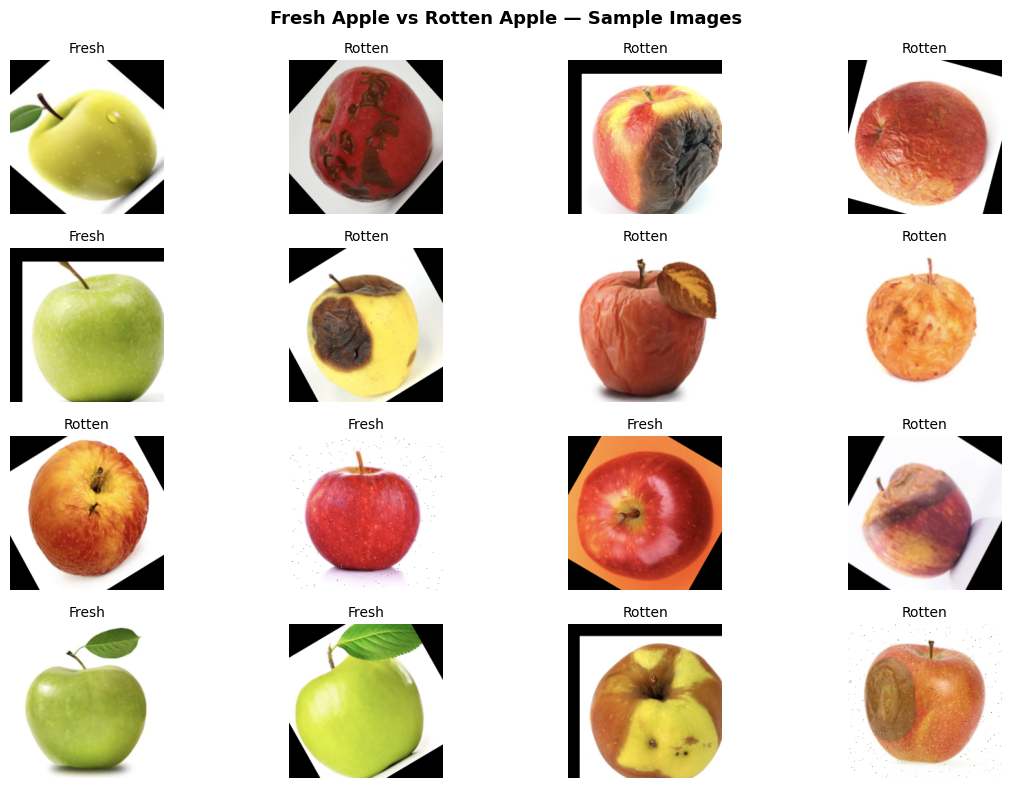

In [48]:
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    label_idx = int(fixed_labels[i][0])
    plt.title(class_names[label_idx], fontsize=10)
    plt.axis('off')

plt.suptitle('Fresh Apple vs Rotten Apple — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir + 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()


## STEP 12: Optimise the Data Pipeline
`.cache()`, `.shuffle()`, and `.prefetch()` build an efficient input pipeline:
- `.cache()` stores batches in RAM after the first epoch, avoiding repeated disk reads
- `.shuffle(1000)` randomises sample order so the model doesn't learn file ordering
- `.prefetch(AUTOTUNE)` overlaps data preprocessing with model training


In [49]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset  = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print('Pipeline optimised with cache + shuffle + prefetch.')


Pipeline optimised with cache + shuffle + prefetch.


## STEP 13: Define the Data Augmentation Pipeline
Data augmentation synthetically expands the training set by randomly transforming each image on
the fly. Validation and test sets are never augmented, only normalised/preprocessed.

- `RandomFlip('horizontal')` — mirrors the image left-right (an apple looks the same either way)
- `RandomRotation(0.15)` — rotates by up to ±15%
- `RandomZoom(0.15)` — zooms in/out by up to 15%
- `RandomContrast(0.15)` — varies contrast, useful since rot spots change colour/contrast


In [50]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
], name='data_augmentation')


## STEP 14: Visualise Augmentation Effects on One Image

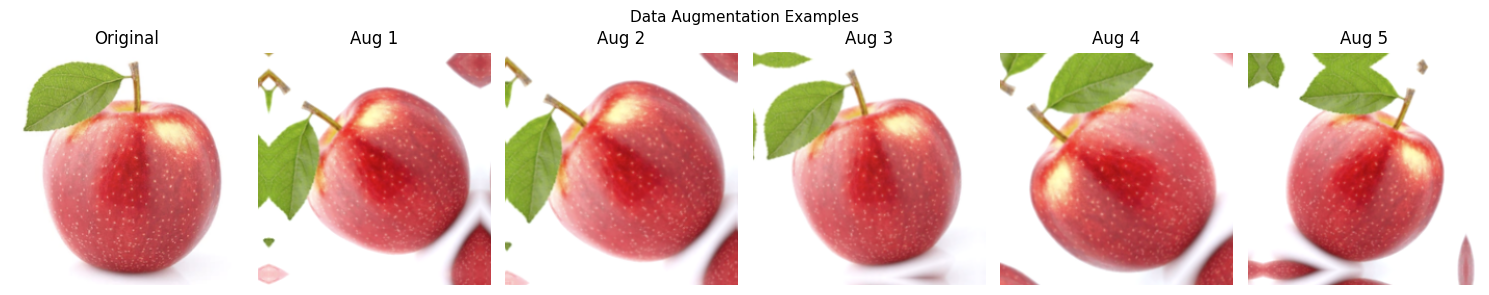

In [51]:
for images, _ in train_dataset.take(1):
    sample = images[0:1]
    break

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 6):
    aug_img = data_augmentation(sample, training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig(results_dir + 'augmentation_examples.png', dpi=120, bbox_inches='tight')
plt.show()


## STEP 15: Define Shared Callbacks and Utility Functions

In [52]:
def make_callbacks(name):
    """Return a fresh set of callbacks for a training run."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'/kaggle/working/models/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=3, min_lr=1e-7, verbose=1,
        ),
    ]


def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(results_dir + f'{safe_title}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()


def evaluate_model(model, dataset, class_names, title='Model'):
    """Evaluate a binary classification model (sigmoid output, threshold 0.5)."""
    y_true, y_pred, y_prob = [], [], []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy().ravel().astype(int))

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f'\n{title}')
    print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred):.4f}')
    print(f'Recall    : {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score  : {f1_score(y_true, y_pred):.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, cmap='Blues', cbar=False, annot=True, fmt='d',
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={'fontsize': 11, 'fontweight': 'bold'}
    )
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(results_dir + f'{safe_title}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()

    return accuracy_score(y_true, y_pred)

print('Callbacks and utility functions defined.')


Callbacks and utility functions defined.


## STEP 16: Build the Transfer Learning Model (MobileNetV2)
Feature-extraction model:
1. Augment input (training only)
2. Preprocess for MobileNetV2 (scales pixels to `[-1, 1]`)
3. Frozen MobileNetV2 backbone (`include_top=False`, ImageNet weights)
4. `GlobalAveragePooling2D`
5. Dense classification head → single sigmoid unit (binary output)


In [53]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

def build_transfer_model(input_shape, augmentation):
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet',
        input_shape=input_shape,
        include_top=False,
    )
    preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input

    # Freeze the base model for the feature-extraction phase
    base_model.trainable = False
    print(f'Base model      : {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')

    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x)                     # scale pixels to [-1, 1]
    x = base_model(x, training=False)          # frozen inference mode
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs, name='mobilenetv2_transfer'), base_model


tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model      : mobilenetv2_1.00_224
Trainable layers: 0 / 154


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## STEP 17: Compile and Train (Feature-Extraction Phase)
A small learning rate (`1e-4`) avoids large gradient updates corrupting the head before it has
converged.


In [54]:
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

tl_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('mobilenetv2_feature_extraction'),
    verbose=1,
)


Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 869ms/step - accuracy: 0.8223 - loss: 0.3944
Epoch 1: val_accuracy improved from None to 0.97638, saving model to /kaggle/working/models/mobilenetv2_feature_extraction_best.keras

Epoch 1: finished saving model to /kaggle/working/models/mobilenetv2_feature_extraction_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 121s 911ms/step - accuracy: 0.9021 - loss: 0.2587 - val_accuracy: 0.9764 - val_loss: 0.0978 - learning_rate: 1.0000e-04
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 871ms/step - accuracy: 0.9638 - loss: 0.1146
Epoch 2: val_accuracy improved from 0.97638 to 0.98425, saving model to /kaggle/working/models/mobilenetv2_feature_extraction_best.keras

Epoch 2: finished saving model to /kaggle/working/models/mobilenetv2_feature_extraction_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 113s 897ms/step - accuracy: 0.9677 - loss: 0.1015 - val_accuracy: 0.9843 - val_loss: 0.0617 - learning_rate: 1.0000e-04
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step -

## STEP 18: Evaluate the Transfer Learning Model on the Validation Set

MobileNetV2 TL -> val_loss: 0.0232
MobileNetV2 TL -> val_accuracy: 0.9921


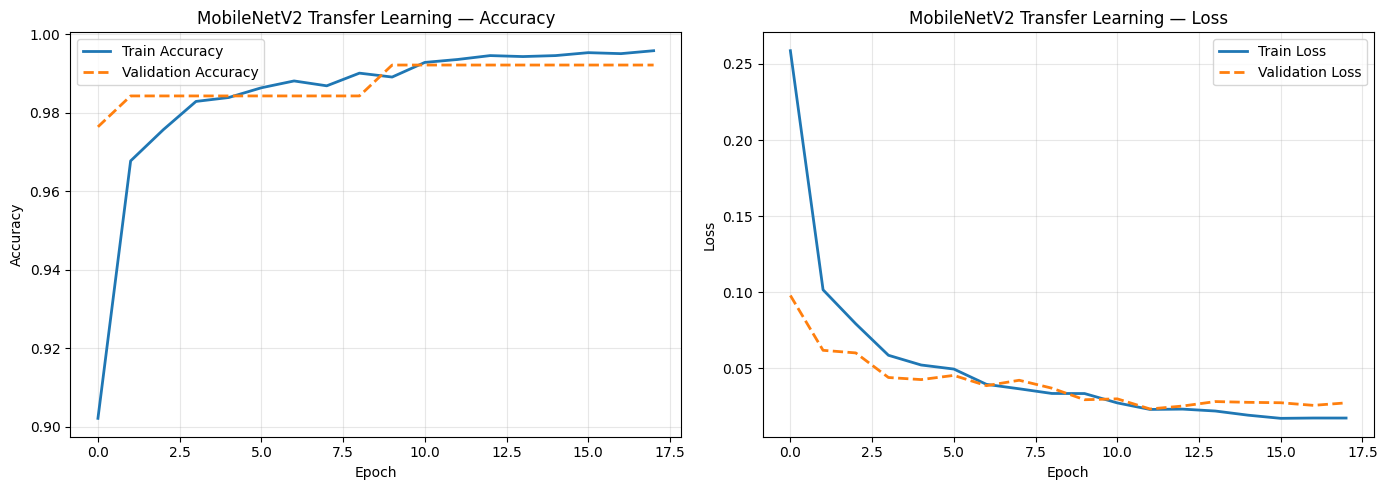

In [55]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV2 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV2 TL -> val_accuracy: {tl_val_acc:.4f}')

plot_learning_curves(tl_history, 'MobileNetV2 Transfer Learning')


## STEP 19: Evaluate the Transfer Learning Model on the Test Set

2026-07-21 22:06:57.426014: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



MobileNetV2 Transfer
Accuracy  : 0.9955
Precision : 0.9942
Recall    : 0.9981
F1-Score  : 0.9961

Classification Report:
              precision    recall  f1-score   support

       Fresh     0.9972    0.9918    0.9945       365
      Rotten     0.9942    0.9981    0.9961       515

    accuracy                         0.9955       880
   macro avg     0.9957    0.9949    0.9953       880
weighted avg     0.9955    0.9955    0.9955       880



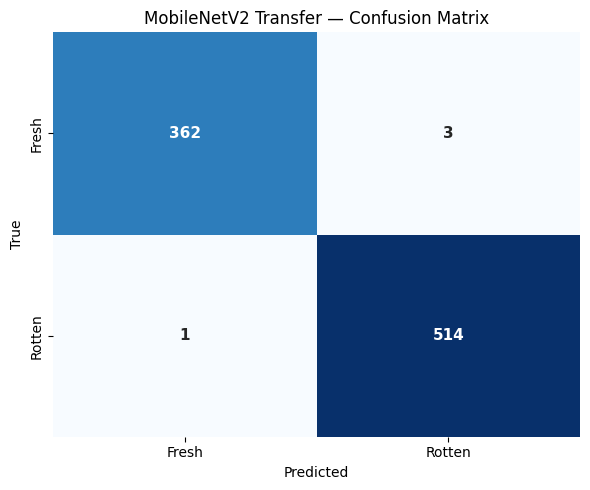

In [56]:
tl_test_acc = evaluate_model(tl_model, test_dataset, class_names, 'MobileNetV2 Transfer')


## STEP 20: Fine-Tuning (Unfreeze Top Layers)
Once the classification head has converged, unfreeze the top layers of the backbone and continue
training at a much lower learning rate. This lets the pre-trained features adapt slightly to the
apple domain, typically boosting accuracy a few points further.


In [57]:
# Unfreeze the top 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')


Trainable base layers after unfreezing: 30 / 154


## STEP 21: Recompile with a 10× Smaller Learning Rate

In [58]:
FINETUNE_LR = LR / 10

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)


## STEP 22: Continue Training (Fine-Tuning Phase)

In [59]:
ft_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=make_callbacks('mobilenetv2_finetuned'),
    verbose=1,
)


Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9547 - loss: 0.1120
Epoch 1: val_accuracy improved from None to 0.98425, saving model to /kaggle/working/models/mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to /kaggle/working/models/mobilenetv2_finetuned_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.9652 - loss: 0.0894 - val_accuracy: 0.9843 - val_loss: 0.0661 - learning_rate: 1.0000e-05
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9837 - loss: 0.0495
Epoch 2: val_accuracy did not improve from 0.98425
126/126 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9819 - loss: 0.0519 - val_accuracy: 0.9843 - val_loss: 0.0453 - learning_rate: 1.0000e-05
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9880 - loss: 0.0364
Epoch 3: val_accuracy did not improve from 0.98425
126/126 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9881 - loss: 0.0367 - val_accuracy: 0.9843 - val_loss: 0.0439 - learning_rate: 

## STEP 23: Visualise Fine-Tuning Learning Curves
Expect a modest additional boost in accuracy. If the dataset is small, the improvement may be marginal, or validation loss may start to rise — that's the EarlyStopping callback's job to catch.

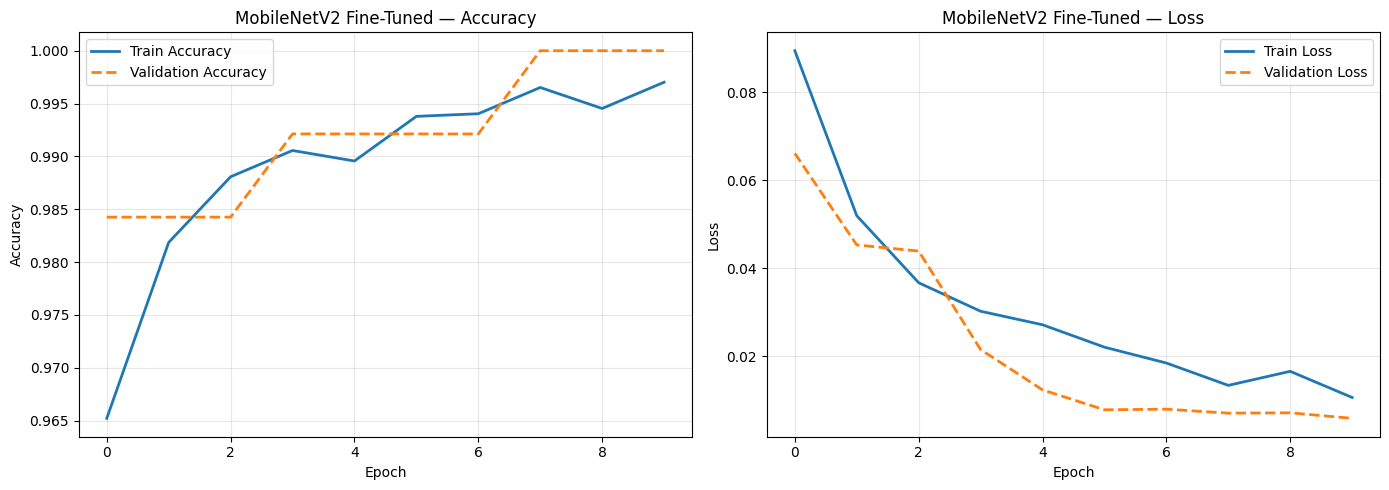

In [60]:
plot_learning_curves(ft_history, 'MobileNetV2 Fine-Tuned')


## STEP 24: Evaluate the Fine-Tuned Model on the Test Set

2026-07-21 22:30:51.734684: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



MobileNetV2 Fine-Tuned
Accuracy  : 0.9966
Precision : 1.0000
Recall    : 0.9942
F1-Score  : 0.9971

Classification Report:
              precision    recall  f1-score   support

       Fresh     0.9918    1.0000    0.9959       365
      Rotten     1.0000    0.9942    0.9971       515

    accuracy                         0.9966       880
   macro avg     0.9959    0.9971    0.9965       880
weighted avg     0.9966    0.9966    0.9966       880



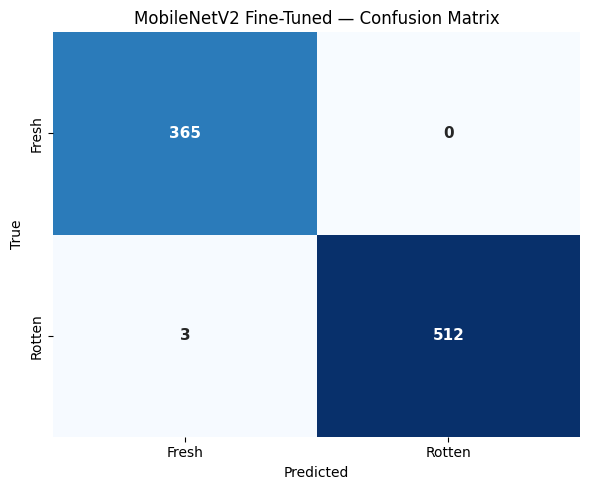


--- Summary ---
Feature-extraction test accuracy : 0.9955
Fine-tuned test accuracy         : 0.9966


In [61]:
ft_test_acc = evaluate_model(tl_model, test_dataset, class_names, 'MobileNetV2 Fine-Tuned')

print('\n--- Summary ---')
print(f'Feature-extraction test accuracy : {tl_test_acc:.4f}')
print(f'Fine-tuned test accuracy         : {ft_test_acc:.4f}')


## STEP 25: Predict on a New Image (Optional Sanity Check)
Update `img_path` below to any single apple image on disk (e.g. one you upload separately to
Kaggle) to see the model's prediction before deployment.


In [62]:
def predict_image(img_path, model, class_names, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    """Load an image file and classify it with the trained model."""
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)          # [0, 255] float32
    img_array = np.expand_dims(img_array, axis=0)          # (1, H, W, 3)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    prob = model.predict(img_array, verbose=0)[0][0]
    label = class_names[int(prob >= 0.5)]
    confidence = prob if prob >= 0.5 else 1 - prob
    print(f'Prediction: {label}  (confidence={confidence:.4f})')

# Example (uncomment and set a real path to test):
# predict_image('/kaggle/input/your-test-image.jpg', tl_model, class_names)


## STEP 26: Save the Final Model
This is the deployable model file (`model.keras`) for the cloud deployment stage of the
assignment.


In [63]:
FINAL_MODEL_PATH = '/kaggle/working/model.keras'
tl_model.save(FINAL_MODEL_PATH)

print('Model saved:')
print(f' {FINAL_MODEL_PATH}')
print(f' Final test accuracy: {ft_test_acc:.4f}')


Model saved:
 /kaggle/working/model.keras
 Final test accuracy: 0.9966


---
### Notes for the write-up
- **Model:** MobileNetV2 (ImageNet weights) → frozen feature extraction, then fine-tuned on the
  top 30 layers.
- **Input size:** 224×224×3 (MobileNetV2's native ImageNet input size).
- **Loss / activation:** Binary crossentropy with a single sigmoid output unit — standard for a
  two-class problem (Fresh Apple = 0, Rotten Apple = 1, order depends on the alphabetical folder
  names Keras discovered — see `class_names` printed in STEP 10).
- **Why no GPU code:** Kaggle's free tier gives CPU-only sessions unless you explicitly enable a
  GPU accelerator (which has a weekly quota). This notebook runs correctly either way — STEP 4
  simply reports what hardware is available.
- **Deployment artifact:** `/kaggle/working/model.keras` — download this from the Kaggle output
  panel after the notebook finishes running, ready for the cloud deployment stage of the
  assignment.
